In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
# Which countries are driving the highest total profit, and which ones are operating at a net loss?

In [66]:
df = pd.read_csv(r'C:\Users\Marcus\Desktop\python pandas\superstore_data\version_control\superstore_clean.csv')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,31518,CA-2012-169397,2012-12-24,27-12-2012,First Class,JB-15925,Joni Blumstein,Consumer,Dublin,Ohio,...,OFF-BI-10002852,Office Supplies,Binders,Ibico Standard Transparent Covers,19.7760,4,0.70,-13.84,0.79,Medium
1,6224,US-2011-144729,2011-07-21,24-07-2011,First Class,SS-20140,Saphhira Shifley,Corporate,San Miguelito,Panama,...,OFF-FA-10002247,Office Supplies,Fasteners,"Oic Paper Clips, Bulk Pack",11.5440,2,0.40,-5.22,0.97,Medium
2,15333,IT-2014-4749412,2014-09-18,23-09-2014,Standard Class,MB-18085,Mick Brown,Unknown,Birmingham,England,...,OFF-AR-10003113,Office Supplies,Art,"Binney & Smith Pens, Blue",29.8500,5,0.50,-4.80,3.71,Medium
3,49259,NI-2013-4420,2013-04-10,10/10/2013,Standard Class,MP-7965,Michael Paige,Corporate,Lagos,Lagos,...,OFF-AVE-10004512,Office Supplies,Binders,"Avery Hole Reinforcements, Economy",1.3230,1,0.70,-3.09,0.06,Medium
4,24199,IN-2014-14423,2014-10-29,30-10-2014,First Class,DL-12925,Daniel Lacy,Consumer,Kendari,Sulawesi Tenggara,...,FUR-FU-10002362,Furnitures,Furnishings,"Advantus Door Stop, Black",131.4876,4,0.27,25.17,0.00,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51365,17526,ES-2014-2057259,2014-08-02,5/8/2014,First Class,PB-19150,Philip Brown,Consumer,Cagnes-Sur-Mer,Provence-Alpes-Cote D'Azur,...,OFF-PA-10002616,Office Supplies,Paper,"Green Bar Parchment Paper, Multicolor",108.5400,6,0.00,34.56,11.76,Medium
51366,36055,CA-2011-121573,2011-11-03,"Jul 11, 2011",Standard Class,SG-20605,Speros Goranitis,Consumer,New York City,New York,...,TEC-PH-10000984,Technology,Phones,Panasonic Kx-Tg9471B,783.9600,4,0.00,219.51,64.42,High
51367,43576,TU-2011-9190,2011-12-23,28-12-2011,Second Class,CM-1830,Cari Macintyre,Corporate,Corum,Corum,...,OFF-KIT-10002357,Office Supplies,Appliances,"Kitchenaid Blender, White",39.8400,1,0.60,-12.96,5.84,Medium
51368,22403,IN-2013-35388,2013-08-07,11/8/2013,Standard Class,IM-15055,Unknown,Consumer,Jakarta,Jakarta,...,OFF-AR-10000058,Office Supplies,Art,"Stanley Canvas, Water Color",38.4345,1,0.27,3.66,2.96,Medium


In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51370 entries, 0 to 51369
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51370 non-null  int64  
 1   Order ID        51370 non-null  str    
 2   Order Date      51370 non-null  str    
 3   Ship Date       51370 non-null  str    
 4   Ship Mode       51370 non-null  str    
 5   Customer ID     51370 non-null  str    
 6   Customer Name   51336 non-null  str    
 7   Segment         51370 non-null  str    
 8   City            51351 non-null  str    
 9   State           51339 non-null  str    
 10  Country         51370 non-null  str    
 11  Postal Code     51370 non-null  int64  
 12  Market          51370 non-null  str    
 13  Region          51370 non-null  str    
 14  Product ID      51370 non-null  str    
 15  Category        51370 non-null  str    
 16  Sub-Category    51370 non-null  str    
 17  Product Name    51370 non-null  str    
 1

In [70]:
countries_net_loss_profit = df.groupby(df['Country'])[['Sales','Profit']].agg(
    total_sales = ('Sales','sum'),
    total_profit = ('Profit','sum'),
    median_profit = ('Profit','median'),
).sort_values(by='total_profit', ascending=False).round(2)
countries_net_loss_profit_backup = countries_net_loss_profit
countries_net_loss_profit

,total_sales,total_profit,median_profit
Country,,,
United States,2015211.30,257080.06,8.79
China,634474.39,136813.81,28.62
India,533214.07,117516.30,27.00
France,768986.09,98117.90,16.44
Germany,573808.20,95914.79,19.32
...,...,...,...
Pakistan,54012.07,-20364.82,-17.64
Honduras,83182.29,-27540.12,-10.84
Netherlands,72198.80,-38641.30,-25.72


In [71]:
countries_net_loss_profit.head(10)

,total_sales,total_profit,median_profit
Country,,,
United States,2015211.30,257080.06,8.79
China,634474.39,136813.81,28.62
India,533214.07,117516.30,27.00
France,768986.09,98117.90,16.44
Germany,573808.20,95914.79,19.32
United Kingdom,465945.48,94352.40,19.20
Australia,835224.15,91433.33,9.18
Mexico,556512.74,91315.75,12.42
Spain,261857.34,47827.90,19.98


In [72]:
countries_net_loss_profit.tail(10)

,total_sales,total_profit,median_profit
Country,,,
South Korea,29081.51,-11383.21,-18.81
Sweden,25281.54,-14245.48,-27.28
Philippines,166437.61,-14533.73,-8.26
Panama,47913.24,-16268.05,-8.19
Argentina,48787.43,-16544.69,-11.92
Pakistan,54012.07,-20364.82,-17.64
Honduras,83182.29,-27540.12,-10.84
Netherlands,72198.80,-38641.30,-25.72
Nigeria,49819.81,-73865.86,-28.93


In [74]:
countries_net_loss_profit_ht = pd.concat([
    countries_net_loss_profit.head(10),
    countries_net_loss_profit.tail(10)
])
countries_net_loss_profit_ht

,total_sales,total_profit,median_profit
Country,,,
United States,2015211.30,257080.06,8.79
China,634474.39,136813.81,28.62
India,533214.07,117516.30,27.00
France,768986.09,98117.90,16.44
Germany,573808.20,95914.79,19.32
United Kingdom,465945.48,94352.40,19.20
Australia,835224.15,91433.33,9.18
Mexico,556512.74,91315.75,12.42
Spain,261857.34,47827.90,19.98


In [75]:
countries_net_loss_profit_ht.reset_index(inplace=True)
countries_net_loss_profit_ht

,Country,total_sales,total_profit,median_profit
0,United States,2015211.30,257080.06,8.79
1,China,634474.39,136813.81,28.62
2,India,533214.07,117516.30,27.00
3,France,768986.09,98117.90,16.44
4,Germany,573808.20,95914.79,19.32
5,United Kingdom,465945.48,94352.40,19.20
6,Australia,835224.15,91433.33,9.18
7,Mexico,556512.74,91315.75,12.42
8,Spain,261857.34,47827.90,19.98
9,El Salvador,156030.63,36935.23,18.66


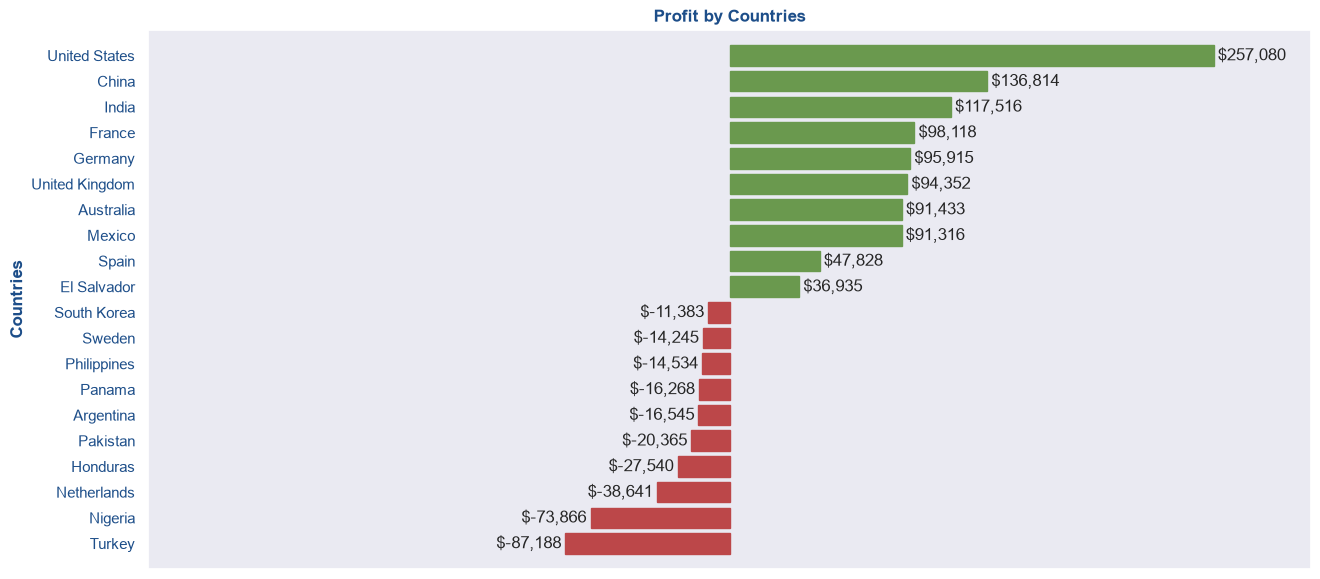

In [173]:
sns.set_theme()

fig, ax = plt.subplots(figsize=(15,7))
ax = sns.barplot(
    data=countries_net_loss_profit_ht,
    x='total_profit',
    y='Country',
    ax=ax
)
ax.margins(x=0.15, y=0.03)
ax.xaxis.set_visible(False) #hides x-axis entirely
ax.grid(False)
ax.set_ylabel('Countries',color='#1d4e89', fontweight="bold")
ax.tick_params(axis='y', labelcolor='#1d4e89')
ax.set_title('Profit by Countries', color='#1d4e89', fontweight="bold")

## ============ centralized 0 axis ============
xmin, xmax = ax.get_xlim()
limit = max(abs(xmin), abs(xmax))  # use the bigger magnitude for both sides
ax.set_xlim(-limit, limit)
n_ticks = 5
neg_ticks = np.linspace(-limit, 0, n_ticks)
pos_ticks = np.linspace(0, limit, n_ticks)
ticks = np.unique(np.concatenate([neg_ticks, pos_ticks]))
ax.set_xticks(ticks)

## ============ show bar values on top of each bar ============
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'${x:,.0f}', padding=3, fontsize=12)

## ============ colorise bar based on its values ============
for bar in ax.patches:
    if bar.get_width() < 0:
        bar.set_color('#bc4749')   # red for losses
    else:
        bar.set_color('#6a994e')   # green for gains


In [ ]:
# Business Question 4:
# Which countries are driving the highest total profit, and which ones are operating at a net loss?

# Answer:
# United States has the highest earning profits by entire country with $250k+ whilst the bottom 3 are Turkey, Nigeria and Netherlands suffer
# almost more than $200k+ losses. The bottom 3 overall losses covers the entire profit gains of United States.